# Wave Data Preparation: Copernicus/EMODnet In-Situ Sea-State Data for WEC Power Estimation

## Purpose

This notebook retrieves, inspects, cleans, and prepares measured in-situ wave observations from the Leixões coastal buoy.

The prepared dataset provides the sea-state time series needed for the next analyses, including simplified WEC power estimation from wave-height and period variables, short-term forecasting, prediction intervals, and storage-aware smoothing metrics.

## Data source

The selected source is the Leixões coastal buoy, available through Copernicus Marine / EMODnet Physics in-situ wave observations.

Useful source pages:

* [EMODnet Map Viewer](https://emodnet.ec.europa.eu/geoviewer/)
* [Leixões platform page on EMODnet Physics](https://map.emodnet-physics.eu/platformpage/?platformcode=Leixoes-coast-buoy&source=cp&integrator=INSTAC)
* [Copernicus Marine product page: Global Ocean - Delayed Mode Wave product](https://data.marine.copernicus.eu/product/INSITU_GLO_WAV_DISCRETE_MY_013_045/description)
* [Copernicus Marine Toolbox documentation](https://toolbox-docs.marine.copernicus.eu/en/stable/)
* [Copernicus Marine product user manual](https://documentation.marine.copernicus.eu/PUM/CMEMS-INS-PUM-013-045.pdf)
* [Copernicus Marine quality information document](https://documentation.marine.copernicus.eu/QUID/CMEMS-INS-QUID-013-045.pdf)

Data citation:

> Global Ocean - Delayed Mode Wave product. E.U. Copernicus Marine Service Information (CMEMS). Marine Data Store (MDS). DOI: [10.17882/70345](https://doi.org/10.17882/70345). Accessed 24 Jun 2026.

## Selected location

The selected platform is the Leixões coastal buoy, located off northern Portugal near the Atlantic coast around Porto.

Portugal has documented ocean-energy activity along its Atlantic coast, including wave-energy testing and demonstration areas such as Aguçadoura and Viana do Castelo. The Leixões buoy is used here as an open measured wave-data source from this broader Atlantic-facing region.

General context reference:

* [IEA-OES Portugal country page](https://www.ocean-energy-systems.org/ocean-energy-in-the-world/portugal/)

## Notebook outputs

The notebook prepares:

* a raw NetCDF file downloaded from Copernicus Marine,
* a processed modelling-ready time series for the following notebooks.


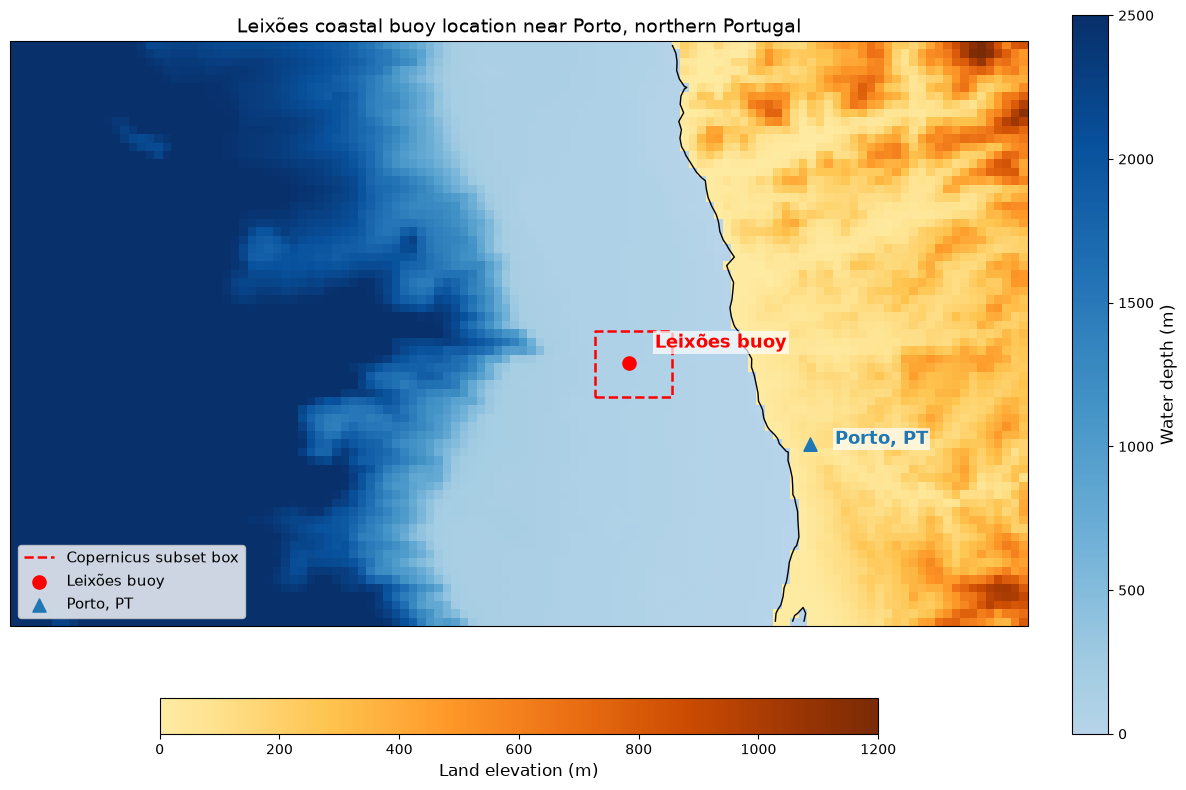

Saved figure to: ../outputs/figures/study_location_leixoes_coastal_buoy.png


In [1]:
import sys
from pathlib import Path

# Make the src/ folder importable from the notebooks/ folder
sys.path.append(str(Path("../src").resolve()))

from geo_plots import plot_near_coast_station_map

# Main Leixões buoy information
LEIXOES_PLATFORM_CODE = "Leixoes-coast-buoy"
LEIXOES_LOCATION_NAME = "leixoes_coastal_buoy"
LEIXOES_BUOY_LATITUDE = 41.317
LEIXOES_BUOY_LONGITUDE = -8.983

# Porto reference location
PORTO_LATITUDE = 41.1579
PORTO_LONGITUDE = -8.6291
PORTO_LABEL = "Porto, PT"

# Copernicus subset box for retrieving the buoy observations later
LEIXOES_SUBSET_MIN_LONGITUDE = -9.05
LEIXOES_SUBSET_MAX_LONGITUDE = -8.90
LEIXOES_SUBSET_MIN_LATITUDE = 41.25
LEIXOES_SUBSET_MAX_LATITUDE = 41.38

# Wider map area for visual context
MAP_MIN_LONGITUDE = -10.20
MAP_MAX_LONGITUDE = -8.20
MAP_MIN_LATITUDE = 40.80
MAP_MAX_LATITUDE = 41.95

# Output path for the saved figure
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STUDY_LOCATION_FIGURE_PATH = (
    FIGURES_DIR / f"study_location_{LEIXOES_LOCATION_NAME}.png"
)

# Plot and save the study-location map
plot_near_coast_station_map(
    station_name="Leixões buoy",
    station_latitude=LEIXOES_BUOY_LATITUDE,
    station_longitude=LEIXOES_BUOY_LONGITUDE,
    city_name="Porto",
    city_label=PORTO_LABEL,
    city_latitude=PORTO_LATITUDE,
    city_longitude=PORTO_LONGITUDE,
    subset_min_longitude=LEIXOES_SUBSET_MIN_LONGITUDE,
    subset_max_longitude=LEIXOES_SUBSET_MAX_LONGITUDE,
    subset_min_latitude=LEIXOES_SUBSET_MIN_LATITUDE,
    subset_max_latitude=LEIXOES_SUBSET_MAX_LATITUDE,
    map_min_longitude=MAP_MIN_LONGITUDE,
    map_max_longitude=MAP_MAX_LONGITUDE,
    map_min_latitude=MAP_MIN_LATITUDE,
    map_max_latitude=MAP_MAX_LATITUDE,
    output_path=STUDY_LOCATION_FIGURE_PATH,
    figure_title="Leixões coastal buoy location near Porto, northern Portugal",
    station_color="red",
    city_color="tab:blue",
    subset_box_color="red",
    max_depth_for_colorbar_m=2500,
    max_land_elevation_for_colorbar_m=1200,
    show=True,
)

print(f"Saved figure to: {STUDY_LOCATION_FIGURE_PATH}")

Map of the study location near the Leixões coastal buoy off northern Portugal. Bathymetry and land elevation are derived from NOAA ETOPO 2022 topography/bathymetry data. The dashed box indicates the spatial subset used later to retrieve buoy observations from Copernicus Marine.

Map background data citation:

> NOAA National Centers for Environmental Information. 2022: ETOPO 2022 15 Arc-Second Global Relief Model. NOAA National Centers for Environmental Information. DOI: [10.25921/fd45-gt74](https://doi.org/10.25921/fd45-gt74). Accessed 24 Jun 2026.

## Data product and variables

The working Copernicus Marine dataset and platform used in this notebook are:

| Item | Value |
|---|---|
| Product | `INSITU_GLO_WAV_DISCRETE_MY_013_045` |
| Dataset ID | `cmems_obs-ins_glo_wav_my_na_irr` |
| Platform | Leixões coastal buoy |
| Platform code | `Leixoes-coast-buoy` |
| Platform type | Mooring |
| Institution / provider | Hydrographic Institute |
| Approximate latitude | `41.317` |
| Approximate longitude | `-8.983` |
| Native sampling observed during testing | Approximately 30 minutes |

The variables requested from Copernicus Marine are:

| Variable | Meaning | Unit | Use in this notebook and later analysis |
|---|---|---:|---|
| `time` | Observation timestamp | UTC datetime | Main time index for wave-data preparation. |
| `latitude` | Platform latitude | degrees north | Confirms station location. |
| `longitude` | Platform longitude | degrees east | Confirms station location. |
| `VHM0` | Spectral significant wave height, `Hm0` | m | Main wave-height variable for later simplified WEC power estimation and forecasting. |
| `VTPK` | Wave period at spectral peak / peak period, `Tp` | s | Main wave-period descriptor for later simplified power-matrix-style analysis. |
| `VTM02` | Spectral moments `(0,2)` wave period, `Tm02` | s | Additional period descriptor. |
| `VTZA` | Average zero-crossing wave period, `Tz` | s | Secondary period descriptor and quality/context variable. |
| `VTMX` | Maximum wave period, `Tmax` | s | Extreme/sea-state context variable. |
| `VTZM` | Period of the highest wave, `Thmax` | s | Extreme-wave context variable. |
| `VAVH` | Average height of highest one-third waves, `H1/3` | m | Secondary wave-height descriptor; useful for comparison with `VHM0`. |
| `VZMX` | Maximum zero-crossing wave height, `Hmax` | m | Extreme-wave context and quality-control support. |
| `VPED` | Wave principal direction at spectral peak | degrees | Directional feature for site characterization and optional forecasting features. |
| `VPSP` | Wave directional spreading at spectral peak | degrees | Directional spreading feature for site characterization. |
| `*_QC` | Quality-control flags for corresponding variables | code | Used to inspect and filter data quality where appropriate. |

## Retrieving raw Copernicus Marine wave observations

The following cell downloads the selected Leixões buoy wave variables from the Copernicus Marine in-situ wave dataset and saves the raw NetCDF file under `../data/raw/`.

The requested variable list includes the wave-height, period, directional, and extreme-wave descriptors confirmed during testing. `VTM10` is also requested here to check whether the spectral moments `(-1,0)` period is available for this platform.

**Copernicus Marine login**

Downloading data with the Copernicus Marine Toolbox requires a Copernicus Marine account.

Registration page:

- [Copernicus Marine registration](https://data.marine.copernicus.eu/register)

After registration, log in once:

In [2]:
#import copernicusmarine
#copernicusmarine.login()

In [3]:
import copernicusmarine

# Raw data output directory
RAW_DATA_DIR = Path("../data/raw")
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Copernicus Marine dataset information
COPERNICUS_PRODUCT_ID = "INSITU_GLO_WAV_DISCRETE_MY_013_045"
COPERNICUS_DATASET_ID = "cmems_obs-ins_glo_wav_my_na_irr"

# Requested time range
LEIXOES_START_DATETIME = "2025-02-02T00:00:00"
LEIXOES_END_DATETIME = "2026-06-24T00:00:00"

# Copernicus Marine creates a station NetCDF file inside this output folder
RAW_DOWNLOAD_FOLDER_NAME = "copernicus_leixoes_wave_20250202_20260624_raw"
RAW_DOWNLOAD_DIR = RAW_DATA_DIR / RAW_DOWNLOAD_FOLDER_NAME
RAW_NETCDF_PATH = RAW_DOWNLOAD_DIR / "Leixoes-coast-buoy.nc"

# Variables requested from the Copernicus Marine in-situ wave product
LEIXOES_WAVE_VARIABLES = [
    "VHM0",    # spectral significant wave height (Hm0)
    "VTPK",    # wave period at spectral peak / peak period (Tp)
    "VTM10",   # spectral moments (-1,0) wave period (Tm-10)
    "VTM02",   # spectral moments (0,2) wave period (Tm02)
    "VTZA",    # average zero-crossing wave period (Tz)
    "VTMX",    # maximum wave period (Tmax)
    "VTZM",    # period of the highest wave (Thmax)
    "VAVH",    # average height of highest one-third waves (H1/3)
    "VZMX",    # maximum zero-crossing wave height (Hmax)
    "VPED",    # wave principal direction at spectral peak
    "VPSP",    # wave directional spreading at spectral peak
]

# Download only if the station NetCDF file is not already present
if RAW_NETCDF_PATH.exists():
    print(f"Raw file already exists, skipping download: {RAW_NETCDF_PATH}")
    download_response = None
else:
    download_response = copernicusmarine.subset(
        dataset_id=COPERNICUS_DATASET_ID,
        variables=LEIXOES_WAVE_VARIABLES,
        minimum_longitude=LEIXOES_SUBSET_MIN_LONGITUDE,
        maximum_longitude=LEIXOES_SUBSET_MAX_LONGITUDE,
        minimum_latitude=LEIXOES_SUBSET_MIN_LATITUDE,
        maximum_latitude=LEIXOES_SUBSET_MAX_LATITUDE,
        start_datetime=LEIXOES_START_DATETIME,
        end_datetime=LEIXOES_END_DATETIME,
        output_directory=str(RAW_DATA_DIR),
        output_filename=RAW_DOWNLOAD_FOLDER_NAME,
    )

    print(f"Downloaded raw file to: {RAW_NETCDF_PATH}")

download_response

Raw file already exists, skipping download: ../data/raw/copernicus_leixoes_wave_20250202_20260624_raw/Leixoes-coast-buoy.nc


/home/laptop500/miniconda3/envs/wave-energy-storage-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Raw data retrieval summary

The downloaded NetCDF file is inspected below to confirm the actual time coverage, platform metadata, retrieved variables, missingness, and whether all requested variables were available for this platform.

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display
pd.set_option("display.max_colwidth", None)

# Open the downloaded raw NetCDF file
raw_ds = xr.open_dataset(RAW_NETCDF_PATH, engine="netcdf4")

# Extract time index and sampling intervals
time_index = pd.to_datetime(raw_ds["time"].values)
time_steps_min = pd.Series(time_index).sort_values().diff().dropna()
time_steps_min = time_steps_min.dt.total_seconds().div(60).round(2)

# Summarize raw file and time coverage
raw_file_summary = pd.DataFrame(
    {
        "Item": [
            "Raw file",
            "File size (MB)",
            "Time records",
            "First timestamp",
            "Last timestamp",
            "Median sampling interval (min)",
            "Most common sampling interval (min)",
        ],
        "Value": [
            str(RAW_NETCDF_PATH),
            round(RAW_NETCDF_PATH.stat().st_size / 1_000_000, 2),
            raw_ds.sizes.get("time", 0),
            time_index.min(),
            time_index.max(),
            time_steps_min.median(),
            time_steps_min.mode().iloc[0],
        ],
    }
)

display(Markdown(raw_file_summary.to_markdown(index=False)))

# Summarize platform metadata
platform_summary = pd.DataFrame(
    {
        "Item": [
            "Platform code",
            "Platform type",
            "Institution",
            "Dataset ID",
            "Latitude",
            "Longitude",
        ],
        "Value": [
            raw_ds.attrs.get("platform_code", ""),
            raw_ds.attrs.get("platform_type", ""),
            raw_ds.attrs.get("institution", ""),
            raw_ds.attrs.get("dataset_id", ""),
            round(float(np.nanmean(raw_ds["latitude"].values)), 6),
            round(float(np.nanmean(raw_ds["longitude"].values)), 6),
        ],
    }
)

display(Markdown(platform_summary.to_markdown(index=False)))

# Summarize requested variable availability and missingness
variable_rows = []

for variable in LEIXOES_WAVE_VARIABLES:
    if variable in raw_ds.data_vars:
        data = raw_ds[variable]
        total_count = data.size
        valid_count = int(data.count().values)
        missing_count = total_count - valid_count
        missing_percent = 100 * missing_count / total_count

        variable_rows.append(
            {
                "Variable": variable,
                "Available": "yes",
                "Standard name": data.attrs.get("standard_name", "").replace("_", " "),
                "Units": data.attrs.get("units", ""),
                "Missing (%)": round(missing_percent, 2),
                "Ancillary variable": data.attrs.get("ancillary_variable", ""),
            }
        )
    else:
        variable_rows.append(
            {
                "Variable": variable,
                "Available": "no",
                "Standard name": "",
                "Units": "",
                "Missing (%)": np.nan,
                "Ancillary variable": "",
            }
        )

variable_summary = pd.DataFrame(variable_rows)

display(Markdown(variable_summary.to_markdown(index=False)))

| Item                                | Value                                                                           |
|:------------------------------------|:--------------------------------------------------------------------------------|
| Raw file                            | ../data/raw/copernicus_leixoes_wave_20250202_20260624_raw/Leixoes-coast-buoy.nc |
| File size (MB)                      | 1.24                                                                            |
| Time records                        | 6223                                                                            |
| First timestamp                     | 2025-02-02 00:56:25                                                             |
| Last timestamp                      | 2025-06-30 23:32:12                                                             |
| Median sampling interval (min)      | 30.0                                                                            |
| Most common sampling interval (min) | 30.0                                                                            |

| Item          | Value                           |
|:--------------|:--------------------------------|
| Platform code | Leixoes-coast-buoy              |
| Platform type | MO                              |
| Institution   | Hydrographic Institute          |
| Dataset ID    | cmems_obs-ins_glo_wav_my_na_irr |
| Latitude      | 41.316666                       |
| Longitude     | -8.983334                       |

| Variable   | Available   | Standard name                                                                       | Units   |   Missing (%) | Ancillary variable   |
|:-----------|:------------|:------------------------------------------------------------------------------------|:--------|--------------:|:---------------------|
| VHM0       | yes         | sea surface wave significant height                                                 | m       |          0.02 | VHM0_QC              |
| VTPK       | yes         | sea surface wave period at variance spectral density maximum                        | s       |          0    | VTPK_QC              |
| VTM10      | no          |                                                                                     |         |        nan    |                      |
| VTM02      | yes         | sea surface wave mean period from variance spectral density second frequency moment | s       |          0    | VTM02_QC             |
| VTZA       | yes         | sea surface wave mean period                                                        | s       |          1.38 | VTZA_QC              |
| VTMX       | yes         | sea surface wave maximum period                                                     | s       |          1.38 | VTMX_QC              |
| VTZM       | yes         | sea surface wave period of highest wave                                             | s       |          1.38 | VTZM_QC              |
| VAVH       | yes         | sea surface wave significant height                                                 | m       |          1.38 | VAVH_QC              |
| VZMX       | yes         | sea surface wave maximum height                                                     | m       |          1.38 | VZMX_QC              |
| VPED       | yes         | sea surface wave from direction at variance spectral density maximum                | degree  |          0    | VPED_QC              |
| VPSP       | yes         | sea surface wave directional spread at variance spectral density maximum            | degree  |          0    | VPSP_QC              |

The retrieved file covers February–June 2025 with a typical 30-minute sampling interval. This multi-month record is used for the following short-term forecasting, prediction-interval, and storage-smoothing examples, but it is not treated as a full annual record. Later analyses therefore do not present annual or seasonal performance conclusions.

`VTM10` was requested as an energy-period-related descriptor for later WEC power estimation, but it was not returned for this platform/file. The following WEC estimation step will therefore use the available period descriptors, mainly `VTPK` and optionally `VTM02` / `VTZA`, with the chosen period variable stated there.

## Quality and sampling intervals checks

This section:

- converts the NetCDF file into a flat table,
- keeps retrieved wave variables and their dataset-declared QC variables,
- lists only QC flags different from `1` / good data,
- plots key wave variables with aligned QC/missingness strips,
- checks whether sampling intervals are concentrated around the 30-minute grid.

Copernicus In Situ QC flag meanings follow the reference table in the [Copernicus In Situ TAC documentation](https://archimer.ifremer.fr/doc/00950/106219/119273.pdf):

| Flag | Meaning |
|---:|---|
| 0 | No QC performed |
| 1 | Good data |
| 2 | Probably good data |
| 3 | Bad data, potentially correctable |
| 4 | Bad data |
| 5 | Value changed |
| 6 | Below detection / quantification |
| 7 | Nominal value |
| 8 | Interpolated value |
| 9 | Missing value |

| Variable   | QC variable   |   QC flag | Meaning                             |   Count |
|:-----------|:--------------|----------:|:------------------------------------|--------:|
| VHM0       | VHM0_QC       |         2 | 2 Probably good data                |       2 |
| VHM0       | VHM0_QC       |         3 | 3 Bad data, potentially correctable |       1 |
| VHM0       | VHM0_QC       |         4 | 4 Bad data                          |       1 |
| VHM0       | VHM0_QC       |       nan | Missing QC flag                     |       1 |
| VTPK       | VTPK_QC       |         2 | 2 Probably good data                |      48 |
| VTM02      | VTM02_QC      |         2 | 2 Probably good data                |       2 |
| VTZA       | VTZA_QC       |       nan | Missing QC flag                     |      86 |
| VTMX       | VTMX_QC       |         2 | 2 Probably good data                |       9 |
| VTMX       | VTMX_QC       |       nan | Missing QC flag                     |      86 |
| VTZM       | VTZM_QC       |         2 | 2 Probably good data                |       2 |
| VTZM       | VTZM_QC       |       nan | Missing QC flag                     |      86 |
| VAVH       | VAVH_QC       |       nan | Missing QC flag                     |      86 |
| VZMX       | VZMX_QC       |       nan | Missing QC flag                     |      86 |

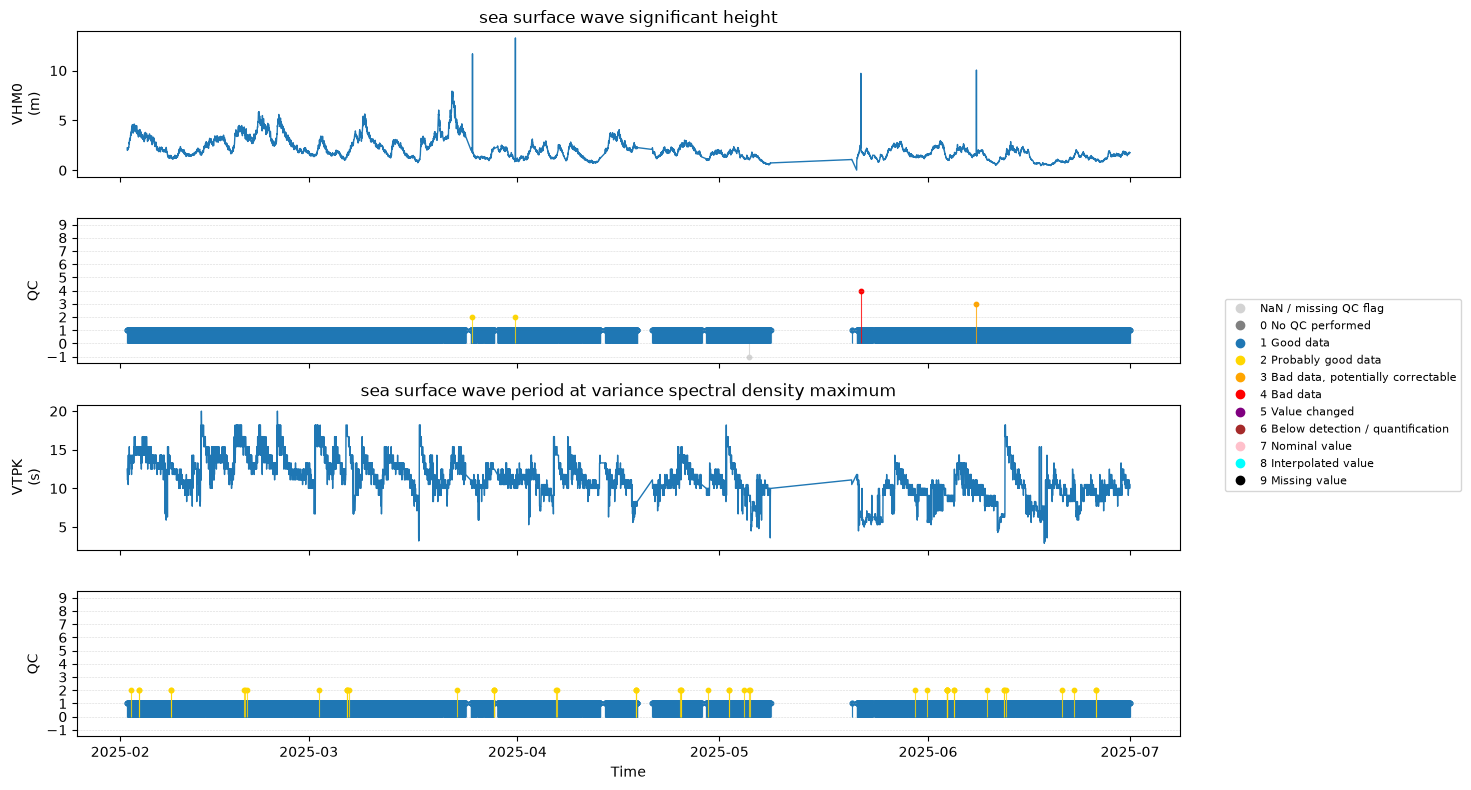

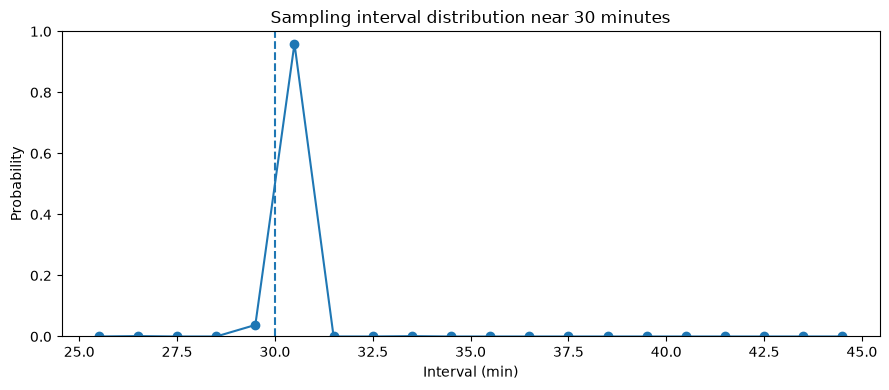

In [5]:
import matplotlib.pyplot as plt

QC_FLAG_LABELS = {
    -1: "NaN / missing QC flag",
     0: "0 No QC performed",
     1: "1 Good data",
     2: "2 Probably good data",
     3: "3 Bad data, potentially correctable",
     4: "4 Bad data",
     5: "5 Value changed",
     6: "6 Below detection / quantification",
     7: "7 Nominal value",
     8: "8 Interpolated value",
     9: "9 Missing value",
}

QC_FLAG_COLORS = {
    -1: "lightgray",
     0: "gray",
     1: "tab:blue",
     2: "gold",
     3: "orange",
     4: "red",
     5: "purple",
     6: "brown",
     7: "pink",
     8: "cyan",
     9: "black",
}

# Convert retrieved variables and their declared QC variables to a flat table
available_wave_variables = [v for v in LEIXOES_WAVE_VARIABLES if v in raw_ds.data_vars]

available_qc_variables = [
    raw_ds[v].attrs.get("ancillary_variable")
    for v in available_wave_variables
]

available_qc_variables = [v for v in available_qc_variables if v in raw_ds.data_vars]

variables_to_extract = list(dict.fromkeys(available_wave_variables + available_qc_variables))

wave_raw_table = raw_ds[variables_to_extract].to_dataframe().reset_index()

if "depth_level" in wave_raw_table.columns and wave_raw_table["depth_level"].nunique() == 1:
    wave_raw_table = wave_raw_table.drop(columns="depth_level")

wave_raw_table["time"] = pd.to_datetime(wave_raw_table["time"])
wave_raw_table = wave_raw_table.sort_values("time").reset_index(drop=True)

# Summarize non-good QC flags only
qc_rows = []

for variable in available_wave_variables:
    qc_variable = raw_ds[variable].attrs.get("ancillary_variable")

    if qc_variable in wave_raw_table.columns:
        counts = wave_raw_table[qc_variable].value_counts(dropna=False).sort_index()

        for flag, count in counts.items():
            if pd.isna(flag):
                qc_rows.append(
                    {
                        "Variable": variable,
                        "QC variable": qc_variable,
                        "QC flag": "NaN",
                        "Meaning": "Missing QC flag",
                        "Count": count,
                    }
                )
            elif flag != 1:
                flag_int = int(flag)
                qc_rows.append(
                    {
                        "Variable": variable,
                        "QC variable": qc_variable,
                        "QC flag": flag_int,
                        "Meaning": QC_FLAG_LABELS.get(flag_int, ""),
                        "Count": count,
                    }
                )

qc_anomaly_summary = pd.DataFrame(qc_rows)

if len(qc_anomaly_summary) > 0:
    display(Markdown(qc_anomaly_summary.to_markdown(index=False)))
else:
    print("No non-good QC flags found.")

# Plot key variables with aligned QC/missingness strips
key_variables = [v for v in ["VHM0", "VTPK"] if v in wave_raw_table.columns]

fig, axes = plt.subplots(len(key_variables) * 2, 1, figsize=(12, 8), sharex=True)

for i, variable in enumerate(key_variables):
    qc_variable = raw_ds[variable].attrs.get("ancillary_variable")
    value_ax = axes[2 * i]
    qc_ax = axes[2 * i + 1]

    # Main variable plot
    value_ax.plot(wave_raw_table["time"], wave_raw_table[variable], linewidth=1)
    value_ax.set_ylabel(f"{variable}\n({raw_ds[variable].attrs.get('units', '')})")
    value_ax.set_title(raw_ds[variable].attrs.get("standard_name", variable).replace("_", " "))

    # QC values as numeric series
    qc_values = wave_raw_table[qc_variable].copy()
    qc_values = qc_values.fillna(-1)

    # Vertical lines and points
    for qc_code, color in QC_FLAG_COLORS.items():
        mask = qc_values == qc_code
        qc_ax.vlines(
            wave_raw_table.loc[mask, "time"],
            0,
            qc_values.loc[mask],
            color=color,
            linewidth=0.8,
            alpha=0.8,
        )
        qc_ax.scatter(
            wave_raw_table.loc[mask, "time"],
            qc_values.loc[mask],
            color=color,
            s=10,
        )

    qc_ax.set_ylabel("QC")
    qc_ax.set_ylim(-1.5, 9.5)
    qc_ax.set_yticks(range(-1, 10))
    qc_ax.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

# Full legend, even for values not present
legend_items = [
    plt.Line2D(
        [0], [0],
        color=QC_FLAG_COLORS[code],
        marker="o",
        linestyle="None",
        markersize=6,
        label=QC_FLAG_LABELS[code],
    )
    for code in range(-1, 10)
]

fig.legend(
    handles=legend_items,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=1,
    frameon=True,
)

axes[-1].set_xlabel("Time")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# Sampling interval probability plot near 30 minutes
time_steps_min = wave_raw_table["time"].diff().dropna().dt.total_seconds().div(60)
near_30_min = time_steps_min[(time_steps_min >= 25) & (time_steps_min <= 45)]

bins = np.arange(25, 46, 1)
counts, bin_edges = np.histogram(near_30_min, bins=bins)
probability = counts / counts.sum()
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(9, 4))
plt.plot(bin_centers, probability, marker="o")
plt.axvline(30, linestyle="--", linewidth=1.5)
plt.title("Sampling interval distribution near 30 minutes")
plt.xlabel("Interval (min)")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The retrieved record is mostly sampled at 30-minute intervals, with one visible data gap around May 2025. The processed table therefore regularizes the data to a 30-minute grid while keeping missing periods as `NaN`.

Most QC flags indicate good data. A small number of non-good or missing QC flags are present, mainly for `VHM0`, `VTPK`, and selected secondary variables.

## Processing and saving data

This section:

- keeps values with QC flags `1` / good and `2` / probably good,
- sets other flagged values to missing,
- renames columns for clearer downstream use,
- aligns observations to a regular 30-minute grid without interpolation,
- saves the processed table to `../data/processed/leixoes_wave_30min_processed.parquet`.

Column renaming used for the processed table:

| Raw variable | Processed name | Meaning |
|---|---|---|
| `VHM0` | `hm0_m` | Spectral significant wave height |
| `VTPK` | `tp_s` | Peak wave period |
| `VTM02` | `tm02_s` | Spectral moments `(0,2)` wave period |
| `VTZA` | `tz_s` | Average zero-crossing wave period |
| `VTMX` | `tmax_s` | Maximum wave period |
| `VTZM` | `thmax_s` | Period of the highest wave |
| `VAVH` | `h13_m` | Average height of highest one-third waves |
| `VZMX` | `hmax_m` | Maximum zero-crossing wave height |
| `VPED` | `dir_peak_deg` | Wave direction at spectral peak |
| `VPSP` | `spread_peak_deg` | Directional spreading at spectral peak |

In [6]:
# Output path
PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_PARQUET_PATH = (
    PROCESSED_DATA_DIR / "leixoes_wave_30min_processed.parquet"
)

# Keep good and probably-good QC flags
QC_ACCEPTED_FLAGS = [1, 2]

wave_clean_table = wave_raw_table.copy()

for variable in available_wave_variables:
    qc_variable = raw_ds[variable].attrs.get("ancillary_variable")

    if qc_variable in wave_clean_table.columns:
        invalid_qc_mask = ~wave_clean_table[qc_variable].isin(QC_ACCEPTED_FLAGS)
        wave_clean_table.loc[invalid_qc_mask, variable] = np.nan

# Rename variables for modelling
rename_columns = {
    "VHM0": "hm0_m",
    "VTPK": "tp_s",
    "VTM02": "tm02_s",
    "VTZA": "tz_s",
    "VTMX": "tmax_s",
    "VTZM": "thmax_s",
    "VAVH": "h13_m",
    "VZMX": "hmax_m",
    "VPED": "dir_peak_deg",
    "VPSP": "spread_peak_deg",
}

processed_columns = ["time", "latitude", "longitude"] + [
    column for column in rename_columns
    if column in wave_clean_table.columns
]

# Align to regular 30-minute grid without interpolation
wave_processed_table = (
    wave_clean_table[processed_columns]
    .assign(time=lambda df: df["time"].dt.round("30min"))
    .rename(columns=rename_columns)
    .groupby("time", as_index=True)
    .mean()
    .asfreq("30min")
    .reset_index()
)

# Save processed output
wave_processed_table.to_parquet(PROCESSED_PARQUET_PATH, index=False)

# Preview
display(wave_processed_table.head())

# Final compact summary
final_summary = pd.DataFrame(
    {
        "Item": [
            "Processed rows",
            "First timestamp",
            "Last timestamp",
            "Columns",
            "Processed output",
        ],
        "Value": [
            len(wave_processed_table),
            wave_processed_table["time"].min(),
            wave_processed_table["time"].max(),
            ", ".join(wave_processed_table.columns),
            str(PROCESSED_PARQUET_PATH),
        ],
    }
)

display(Markdown(final_summary.to_markdown(index=False)))

,time,latitude,longitude,hm0_m,tp_s,tm02_s,tz_s,tmax_s,thmax_s,h13_m,hmax_m,dir_peak_deg,spread_peak_deg
0,2025-02-02 01:00:00,41.316666,-8.983334,2.24,12.5,8.2,8.7,16.4,10.9,2.11,3.21,315.0,16.0
1,2025-02-02 01:30:00,41.316666,-8.983334,2.00,11.8,8.0,8.3,15.6,12.5,1.83,2.93,301.0,19.0
2,2025-02-02 02:00:00,41.316666,-8.983334,2.00,11.1,7.4,8.1,16.4,9.4,1.88,3.46,304.0,22.0
3,2025-02-02 02:30:00,41.316666,-8.983334,2.05,11.1,7.3,7.7,16.4,9.4,1.86,2.72,305.0,24.0
4,2025-02-02 03:00:00,41.316666,-8.983334,2.19,11.8,7.8,8.1,15.6,10.2,1.99,2.92,302.0,18.0


| Item             | Value                                                                                                               |
|:-----------------|:--------------------------------------------------------------------------------------------------------------------|
| Processed rows   | 7150                                                                                                                |
| First timestamp  | 2025-02-02 01:00:00                                                                                                 |
| Last timestamp   | 2025-06-30 23:30:00                                                                                                 |
| Columns          | time, latitude, longitude, hm0_m, tp_s, tm02_s, tz_s, tmax_s, thmax_s, h13_m, hmax_m, dir_peak_deg, spread_peak_deg |
| Processed output | ../data/processed/leixoes_wave_30min_processed.parquet                                                              |

Saved processed table to: ../data/processed/leixoes_wave_30min_processed.parquet


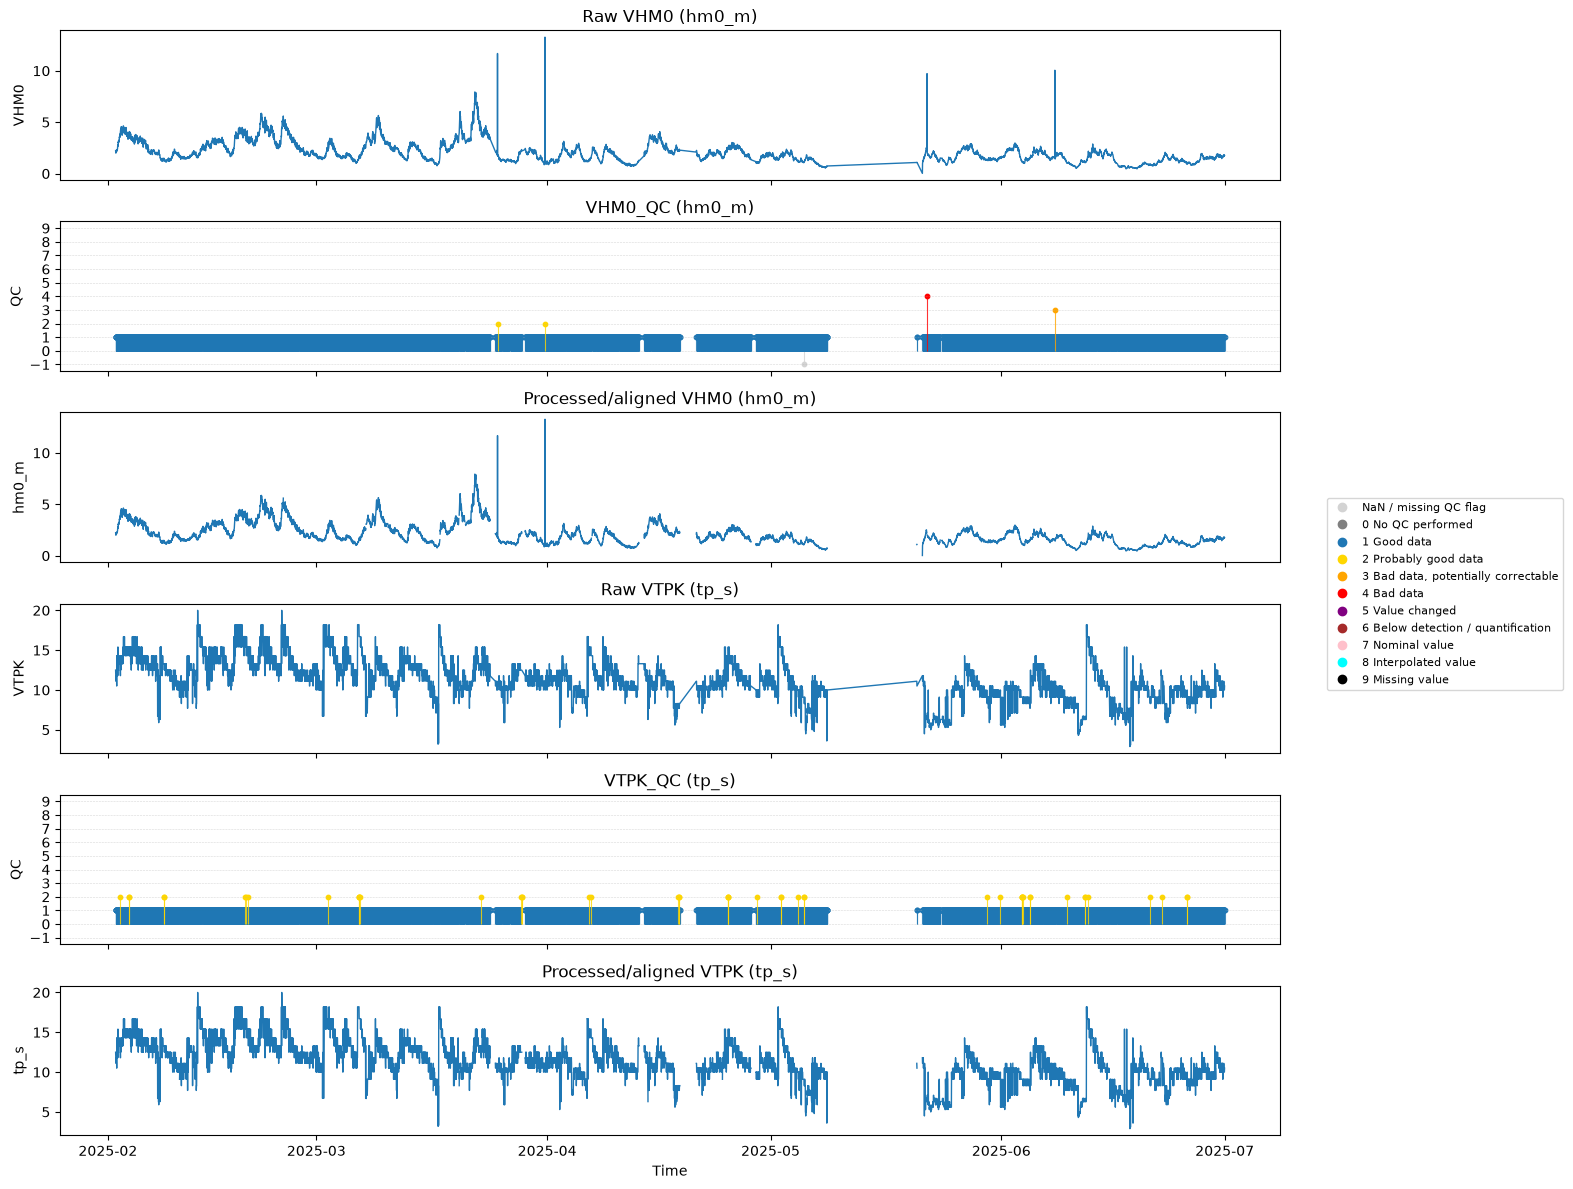

Saved comparison figure to: ../outputs/figures/raw_qc_processed_comparison_leixoes_coastal_buoy.png


In [10]:
# Compare raw, QC, and processed/aligned key variables
comparison_pairs = [
    ("VHM0", "hm0_m"),
    ("VTPK", "tp_s"),
]

fig, axes = plt.subplots(6, 1, figsize=(13, 12), sharex=True)

for i, (raw_variable, processed_variable) in enumerate(comparison_pairs):
    qc_variable = raw_ds[raw_variable].attrs.get("ancillary_variable")

    raw_ax = axes[3 * i]
    qc_ax = axes[3 * i + 1]
    processed_ax = axes[3 * i + 2]

    # Raw
    raw_ax.plot(wave_raw_table["time"], wave_raw_table[raw_variable], linewidth=1)
    raw_ax.set_title(f"Raw {raw_variable} ({processed_variable})")
    raw_ax.set_ylabel(raw_variable)

    # QC
    qc_values = wave_raw_table[qc_variable].copy().fillna(-1)

    for qc_code, color in QC_FLAG_COLORS.items():
        mask = qc_values == qc_code
        qc_ax.vlines(
            wave_raw_table.loc[mask, "time"],
            0,
            qc_values.loc[mask],
            color=color,
            linewidth=0.8,
            alpha=0.8,
        )
        qc_ax.scatter(
            wave_raw_table.loc[mask, "time"],
            qc_values.loc[mask],
            color=color,
            s=10,
        )

    qc_ax.set_title(f"{qc_variable} ({processed_variable})")
    qc_ax.set_ylabel("QC")
    qc_ax.set_ylim(-1.5, 9.5)
    qc_ax.set_yticks(range(-1, 10))
    qc_ax.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

    # Processed
    processed_ax.plot(
        wave_processed_table["time"],
        wave_processed_table[processed_variable],
        linewidth=1,
    )
    processed_ax.set_title(f"Processed/aligned {raw_variable} ({processed_variable})")
    processed_ax.set_ylabel(processed_variable)

# Legend outside on the right
legend_items = [
    plt.Line2D(
        [0], [0],
        color=QC_FLAG_COLORS[code],
        marker="o",
        linestyle="None",
        markersize=6,
        label=QC_FLAG_LABELS[code],
    )
    for code in range(-1, 10)
]

fig.legend(
    handles=legend_items,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    ncol=1,
    frameon=True,
)

axes[-1].set_xlabel("Time")

plt.tight_layout(rect=[0, 0, 1, 1])
fig.savefig(FIGURES_DIR / f"raw_qc_processed_comparison_{LEIXOES_LOCATION_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved comparison figure to: {FIGURES_DIR / f'raw_qc_processed_comparison_{LEIXOES_LOCATION_NAME}.png'}")